In [101]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
abdallahwagih_mall_customers_segmentation_path = kagglehub.dataset_download('abdallahwagih/mall-customers-segmentation')

print('Data source import complete.')


Using Colab cache for faster access to the 'mall-customers-segmentation' dataset.
Data source import complete.


In [102]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mall-customers-segmentation/Mall_Customers.csv


In [103]:
import os

# Load dataset
df = pd.read_csv(os.path.join(abdallahwagih_mall_customers_segmentation_path, 'Mall_Customers.csv'))

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [104]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


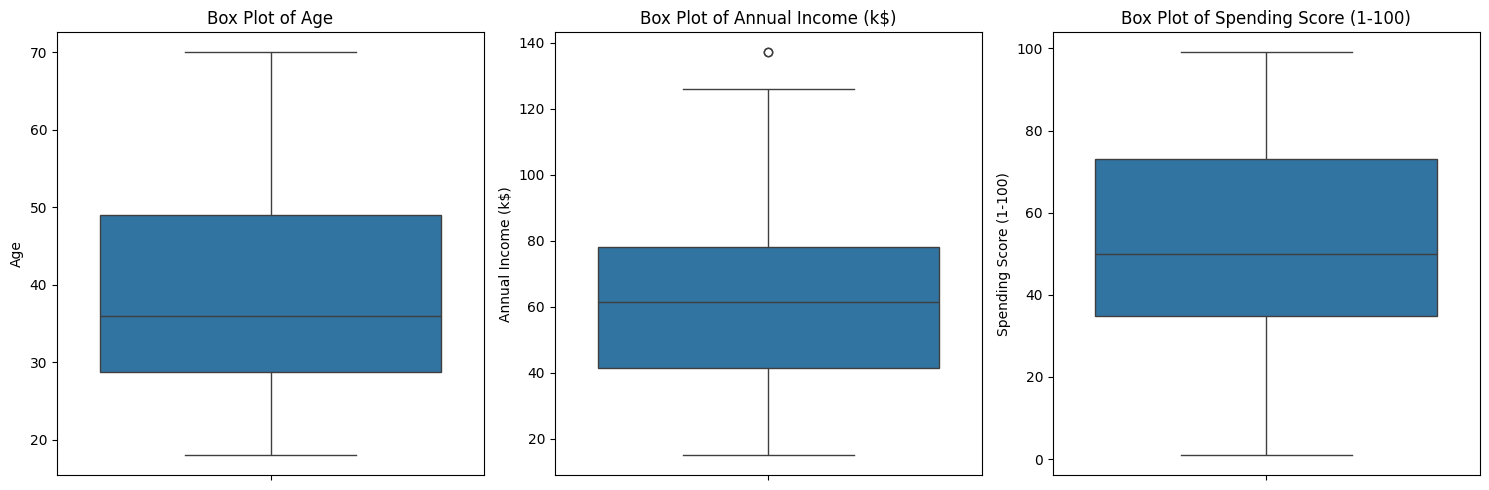

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [106]:
df.duplicated().sum()

np.int64(0)

In [107]:
df1=df.copy()

In [108]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].copy()

In [109]:
X['Spending_Efficiency'] = X['Spending Score (1-100)'] / X['Annual Income (k$)']

In [110]:
X = X.drop(['Spending Score (1-100)', 'Annual Income (k$)'], axis=1)

In [111]:
print(X)

     Age  Spending_Efficiency
0     19             2.600000
1     21             5.400000
2     20             0.375000
3     23             4.812500
4     31             2.352941
..   ...                  ...
195   35             0.658333
196   45             0.222222
197   32             0.587302
198   32             0.131387
199   30             0.605839

[200 rows x 2 columns]


In [112]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

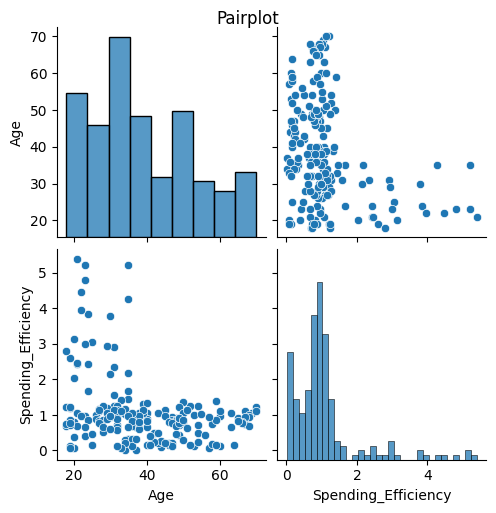

In [113]:
sns.pairplot(X)
plt.suptitle("Pairplot",y=1.01)
plt.show()

In [114]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [115]:
from sklearn.metrics import silhouette_score

def evaluate_model(labels, X):
    # Number of clusters (ignore noise = -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if n_clusters <= 1:
        return n_clusters, None, None

    # Remove noise for silhouette
    mask = labels != -1
    sil_score = silhouette_score(X[mask], labels[mask])

    # Noise ratio
    noise_ratio = np.sum(labels == -1) / len(labels)

    return n_clusters, sil_score, noise_ratio

In [116]:
k_values = range(2, 11)
k_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    k_scores.append(score)

In [117]:
for k, score in zip(k_values, k_scores):
    print(f"k={k}: {score:.3f}")

k=2: 0.420
k=3: 0.502
k=4: 0.409
k=5: 0.427
k=6: 0.385
k=7: 0.403
k=8: 0.449
k=9: 0.435
k=10: 0.429


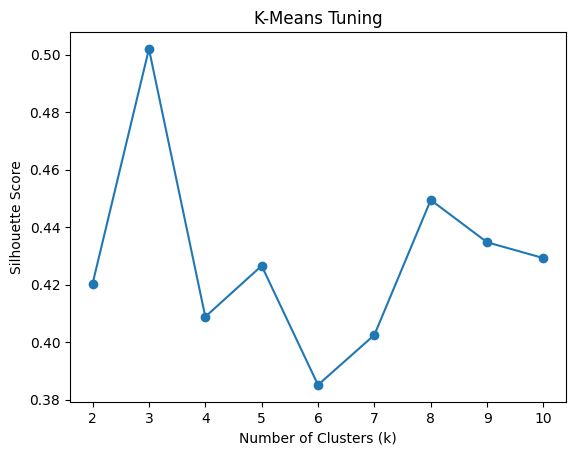

In [118]:
plt.plot(k_values, k_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('K-Means Tuning')
plt.show()

In [119]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
labels_km = kmeans.fit_predict(X_scaled)

km_clusters, km_sil, km_noise = evaluate_model(labels_km, X_scaled)

In [120]:
df['Cluster'] = labels_km
cluster_profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,54.039474,57.486842,36.184211
1,30.442308,70.028846,55.182692
2,24.850000,23.000000,77.550000


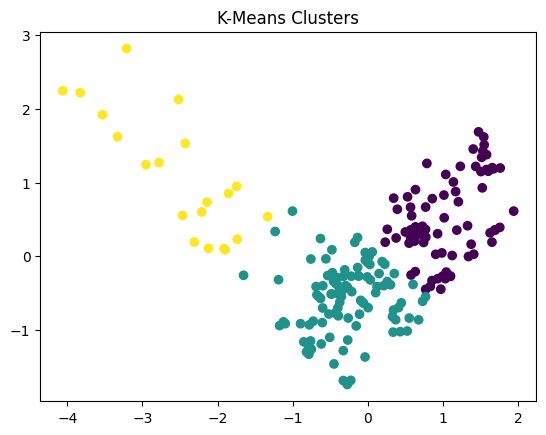

In [121]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_km)
plt.title("K-Means Clusters")
plt.show()

In [122]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps_values = np.arange(0.1, 1.1, 0.001)

results = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)

    # Number of clusters (ignore noise)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Noise ratio
    noise_ratio = np.sum(labels == -1) / len(labels)

    # Skip bad cases
    if n_clusters < 2 or n_clusters > 7 or noise_ratio >= 0.40:
        continue

    # Remove noise
    mask = labels != -1

    # Silhouette score
    score = silhouette_score(X_scaled[mask], labels[mask])

    if score < 0.3:
        continue

    results.append((eps, n_clusters, score, noise_ratio))

# Show results
for r in results:
    print(f"eps={r[0]:.3f}, clusters={r[1]}, silhouette={r[2]:.3f}, noise={r[3]:.2f}")

eps=0.178, clusters=7, silhouette=0.520, noise=0.39
eps=0.179, clusters=7, silhouette=0.520, noise=0.39
eps=0.180, clusters=7, silhouette=0.520, noise=0.39
eps=0.181, clusters=7, silhouette=0.520, noise=0.39
eps=0.182, clusters=7, silhouette=0.520, noise=0.38
eps=0.183, clusters=7, silhouette=0.520, noise=0.38
eps=0.184, clusters=7, silhouette=0.520, noise=0.38
eps=0.185, clusters=7, silhouette=0.520, noise=0.38
eps=0.186, clusters=7, silhouette=0.520, noise=0.38
eps=0.187, clusters=7, silhouette=0.513, noise=0.36
eps=0.188, clusters=7, silhouette=0.513, noise=0.36
eps=0.189, clusters=7, silhouette=0.513, noise=0.36
eps=0.190, clusters=7, silhouette=0.513, noise=0.36
eps=0.191, clusters=7, silhouette=0.513, noise=0.36
eps=0.192, clusters=7, silhouette=0.514, noise=0.35
eps=0.193, clusters=7, silhouette=0.514, noise=0.35
eps=0.194, clusters=7, silhouette=0.514, noise=0.35
eps=0.195, clusters=7, silhouette=0.514, noise=0.35
eps=0.196, clusters=7, silhouette=0.514, noise=0.35
eps=0.197, c

In [123]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.778, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)

db_clusters, db_sil, db_noise = evaluate_model(labels_db, X_scaled)

In [124]:
df['DBSCAN_Cluster'] = labels_db
df['DBSCAN_Cluster'].value_counts()

,count
DBSCAN_Cluster,
0,191
1,5
-1,4


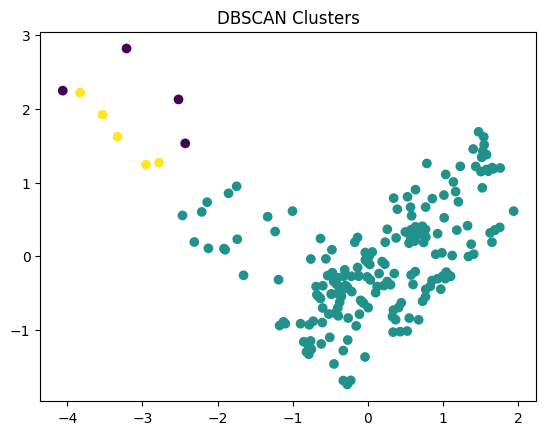

In [125]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_db)
plt.title("DBSCAN Clusters")
plt.show()

In [126]:
best_k_kmeans = k_values[np.argmax(k_scores)]
print(best_k_kmeans)

3


The best number of clusters for Agglomerative Clustering based on Silhouette Score is: 2


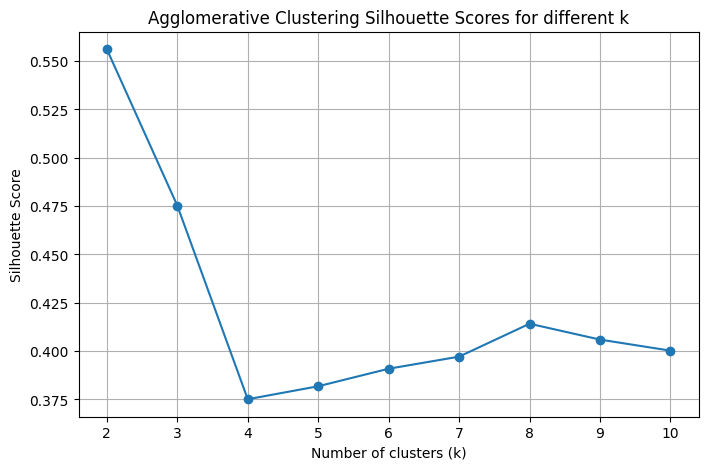

In [127]:
from sklearn.cluster import AgglomerativeClustering

k_values_agg = range(2, 11)
agg_scores = []

for k in k_values_agg:
    agg = AgglomerativeClustering(n_clusters=k)
    labels = agg.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    agg_scores.append(score)

best_k_agg = k_values_agg[np.argmax(agg_scores)]
print(f"The best number of clusters for Agglomerative Clustering based on Silhouette Score is: {best_k_agg}")

plt.figure(figsize=(8, 5))
plt.plot(k_values_agg, agg_scores, marker='o')
plt.title('Agglomerative Clustering Silhouette Scores for different k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()


In [128]:
print("Silhouette scores for Agglomerative Clustering for different k values:")
for k, score in zip(k_values_agg, agg_scores):
    print(f"k={k}: {score:.3f}")

Silhouette scores for Agglomerative Clustering for different k values:
k=2: 0.556
k=3: 0.475
k=4: 0.375
k=5: 0.382
k=6: 0.391
k=7: 0.397
k=8: 0.414
k=9: 0.406
k=10: 0.400


In [129]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=2)
labels_agg = agg.fit_predict(X_scaled)

agg_clusters, agg_sil, agg_noise = evaluate_model(labels_agg, X_scaled)

In [130]:
print(f"Agglomerative Clustering Results:\n  Clusters: {agg_clusters}\n  Silhouette Score: {agg_sil:.3f}\n  Noise Ratio: {agg_noise:.3f}")

Agglomerative Clustering Results:
  Clusters: 2
  Silhouette Score: 0.556
  Noise Ratio: 0.000


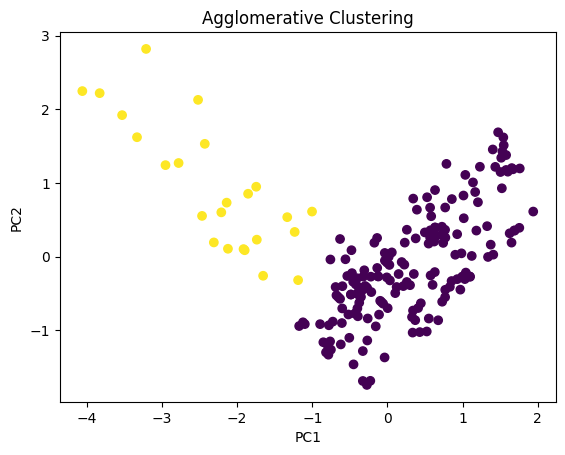

In [131]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_agg)
plt.title("Agglomerative Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

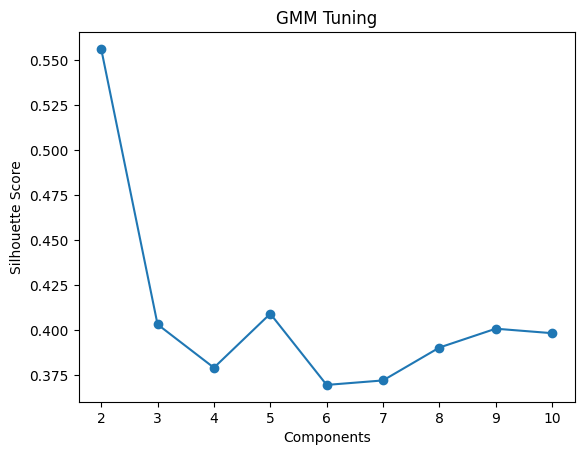

In [132]:
from sklearn.mixture import GaussianMixture

gmm_scores = []

for k in range(2, 11):
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    gmm_scores.append(score)

plt.plot(range(2,11), gmm_scores, marker='o')
plt.xlabel('Components')
plt.ylabel('Silhouette Score')
plt.title('GMM Tuning')
plt.show()

In [133]:
for i, score in enumerate(gmm_scores):
    n_component = i + 2 # Components start from 2
    print(f"n_component={n_component}: {score:.3f}")

n_component=2: 0.556
n_component=3: 0.403
n_component=4: 0.379
n_component=5: 0.409
n_component=6: 0.370
n_component=7: 0.372
n_component=8: 0.390
n_component=9: 0.401
n_component=10: 0.398


In [134]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=2, random_state=42)
labels_gmm = gmm.fit_predict(X_scaled)

gmm_clusters, gmm_sil, gmm_noise = evaluate_model(labels_gmm, X_scaled)

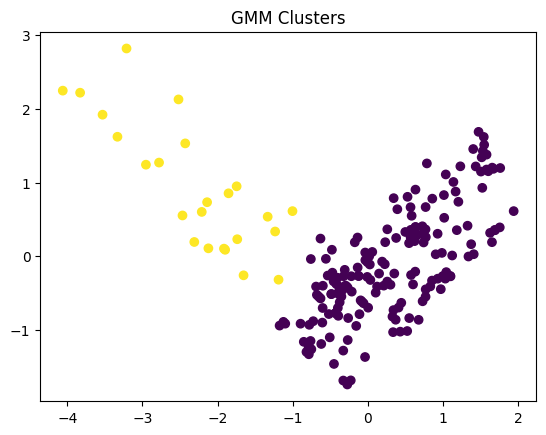

In [135]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_gmm)
plt.title("GMM Clusters")
plt.show()

In [136]:
results = pd.DataFrame({
    'Model': ['K-Means', 'DBSCAN', 'Hierarchical', 'GMM'],
    'Clusters': [km_clusters, db_clusters, agg_clusters, gmm_clusters],
    'Silhouette Score': [km_sil, db_sil, agg_sil, gmm_sil],
    'Noise Ratio': [km_noise, db_noise, agg_noise, gmm_noise]
})

results

,Model,Clusters,Silhouette Score,Noise Ratio
0,K-Means,3,0.502012,0.00
1,DBSCAN,2,0.612623,0.02
2,Hierarchical,2,0.556133,0.00
3,GMM,2,0.556133,0.00


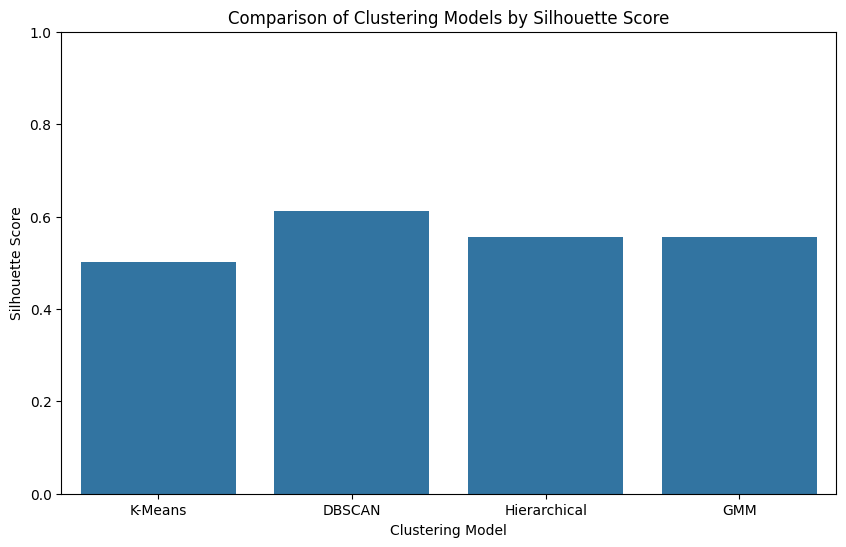

In [137]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Silhouette Score', data=results)
plt.title('Comparison of Clustering Models by Silhouette Score')
plt.xlabel('Clustering Model')
plt.ylabel('Silhouette Score')
plt.ylim(0, 1) # Silhouette scores are between -1 and 1
plt.show()